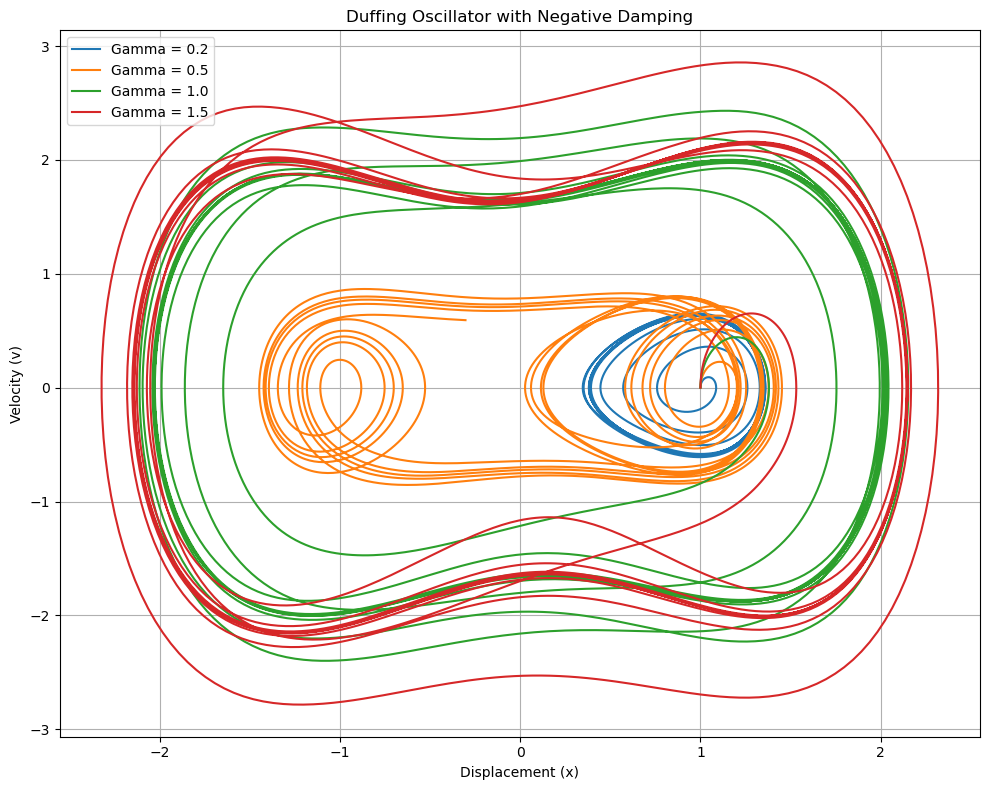

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

delta = 0.3 
alpha = -1
beta = 1
gamma = [0.20,0.28,0.29,0.37, 0.5, 0.65]

gamma = [0.2, 0.5, 1.0, 1.5]
omega = 1.2

def duffing(t, y, alpha, beta, gamma, omega, delta):
    x, v = y
    dxdt = v
    dvdt = -delta * v - alpha * x - beta * x**3 + gamma * np.cos(omega * t)
    return [dxdt, dvdt]

y0 = [1.0, 0.0]
t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 5000)

plt.figure(figsize=(10, 8))

for gam in gamma:
    solution = solve_ivp(
        lambda t, y: duffing(t, y, alpha, beta, gam, omega, delta),
        t_span,
        y0,
        t_eval=t_eval
    )
    
    x = solution.y[0]
    v = solution.y[1]
    
    plt.plot(x, v, label=f'Gamma = {gam}')

plt.title("Duffing Oscillator with Negative Damping")
plt.xlabel("Displacement (x)")
plt.ylabel("Velocity (v)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()